In [1]:
# using Logistic Regression/Random Forest as baseline models
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('future.no_silent_downcasting', True)

In [2]:
df = pd.read_excel("../data/Main_Data_Bank_new.xlsx")
print("✅ 数据读取成功，共有行数:", len(df))
print("✅ 列名如下:")
print(df.columns.tolist())

✅ 数据读取成功，共有行数: 37053
✅ 列名如下:
['ID NR (anonymisert dummy)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'Kommune', 'Fylke', 'Tilskudd i USD', 'NY tilskuddskategori', 'Bransje', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'Bankkunde (1/0)', 'SUM UTLÅN', 'SUM RAMME', 'SUM INNSKUDD', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET', 'BANK WALLET I MNOK', 'Har lån i bank (alle banker)', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mi

In [3]:
df = df.drop(columns=['Bankkunde (1/0)', 'Mislighold 30 og 90 dg ja/nei', 'Misligholdstype', 'SUM UTLÅN','SUM RAMME','SUM INNSKUDD','BANK WALLET', 'Har lån i bank (alle banker)', 'ID NR (anonymisert dummy)','Tilskudd i USD', 'Bransje', 'Total Production Value(NOK)', 'Subsidy Dependency Ratio'])
print(df.columns.tolist())
# 去除列名空格与特殊字符
df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace(r"[^0-9A-Za-z_]", "", regex=True)

# 替换 “ja/nei” 为 1/0
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace({'ja': 1, 'nei': 0, 'Ja': 1, 'Nei': 0, 'JA': 1, 'NEI': 0, '#DIV/0!': 0})

# 将可能的目标列转换为数值
target_col = 'NY_tilskuddskategori'
df[target_col] = df[target_col].replace({"XS" : 0, "S": 1, "M": 2, "L": 3}).astype(float)

# 删除目标缺失值
df = df.dropna(subset=[target_col])
# 拆分 PRODUKSJON
df['PRODUKSJON_list'] = df['PRODUKSJON'].fillna("").apply(lambda x: [s.strip() for s in x.split(",") if s])

# MultiLabelBinarizer
mlb = MultiLabelBinarizer()
produksjon_encoded = pd.DataFrame(mlb.fit_transform(df['PRODUKSJON_list']),
                                  columns=mlb.classes_,
                                  index=df.index)

# 合并回 df
df = pd.concat([df, produksjon_encoded], axis=1)
df = df.drop(columns=['PRODUKSJON', 'PRODUKSJON_list'])
df = pd.get_dummies(df, columns=['Kommune', 'Fylke'], drop_first=True)
df = df.fillna(0)
print(df)

# 输出基本信息
print(f"目标变量 '{target_col}' 值分布：")
print(df[target_col].value_counts())

['Kommune', 'Fylke', 'NY tilskuddskategori', 'PRODUKSJON', 'Kompleks produksjon (1/0)', 'NY KOMMUNESCORE', 'NY KOMMUNESKÅRE FRITID', 'Andre dyr', 'Annet fjørfe', 'Bær', 'Bier', 'Blomster', 'Drivhus', 'Drivhus kg', 'Egg', 'Frukt', 'Geit', 'Geitemelk', 'Gress', 'Gris', 'Griseavl', 'Grønt', 'Hest', 'Korn', 'Kylling', 'Melk', 'Pels', 'Potet', 'Salg av fõr', 'Sau', 'Storfe', 'Økologisk', 'Annet', 'Ingen', 'Produkiv skog', 'Annet fjørfe dyr', 'Bær dekar', 'Egg verpehøns', 'Frukt dekar', 'Geit dyr', 'Gress dekar', 'Gris dyr', 'Grønt dekar', 'Hest dyr', 'Korn dekar', 'Kylling dyr', 'Melk dyr', 'Potet dekar', 'Sau dyr', 'Storfe dyr', 'ENG ja/nei', 'INNSKUDD ja/nei', 'BANK WALLET I MNOK', 'Kundelønnsomhet Lønnsomhet Bankr i Norge', 'Location-Leverage Mismatch Score', 'Loan-to-Production-Value Ratio', 'Production Concentration Index', 'Subsidy_Zone']
       NY_tilskuddskategori  Kompleks_produksjon_10  NY_KOMMUNESCORE  \
0                       3.0                       1                8   
1   

Training set size: (29642, 439), Test set size: (7411, 439)
Class distribution:
NY_tilskuddskategori
1    0.334548
0    0.256767
2    0.235231
3    0.173454
Name: proportion, dtype: float64

=== Logistic Regression Model ===
✅ Logistic Regression Evaluation:
Accuracy: 0.35528268789637024
ROC AUC: 0.7984999770970966

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.06      0.11      1903
           1       0.45      0.35      0.40      2479
           2       0.35      0.32      0.34      1743
           3       0.29      0.84      0.43      1286

    accuracy                           0.36      7411
   macro avg       0.45      0.39      0.32      7411
weighted avg       0.46      0.36      0.32      7411


=== Random Forest Model ===
✅ Random Forest Evaluation:
Accuracy: 0.8314667386317636
ROC AUC: 0.9602331269226282

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.

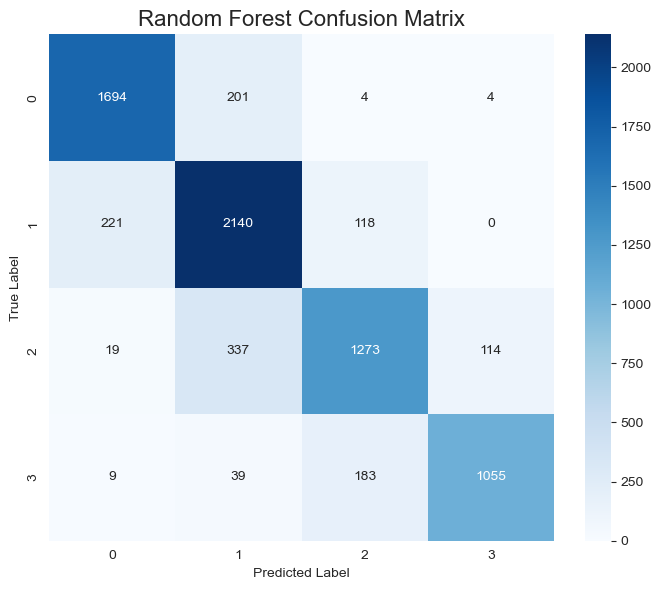


=== Feature Importance Analysis ===
Top 20 Important Features:
                           Feature  Importance
36                     Gress_dekar    0.117896
44                         Sau_dyr    0.076528
52  Production_Concentration_Index    0.072197
45                      Storfe_dyr    0.066315
40                      Korn_dekar    0.062725
42                        Melk_dyr    0.057872
21                            Melk    0.047746
26                          Storfe    0.041291
63                           Gress    0.041271
74                          Storfe    0.038271
69                            Melk    0.037970
25                             Sau    0.036171
0           Kompleks_produksjon_10    0.034115
14                           Gress    0.032939
72                             Sau    0.032191
28                           Annet    0.019457
19                            Korn    0.013705
67                            Korn    0.013330
48              BANK_WALLET_I_MNOK    0.009

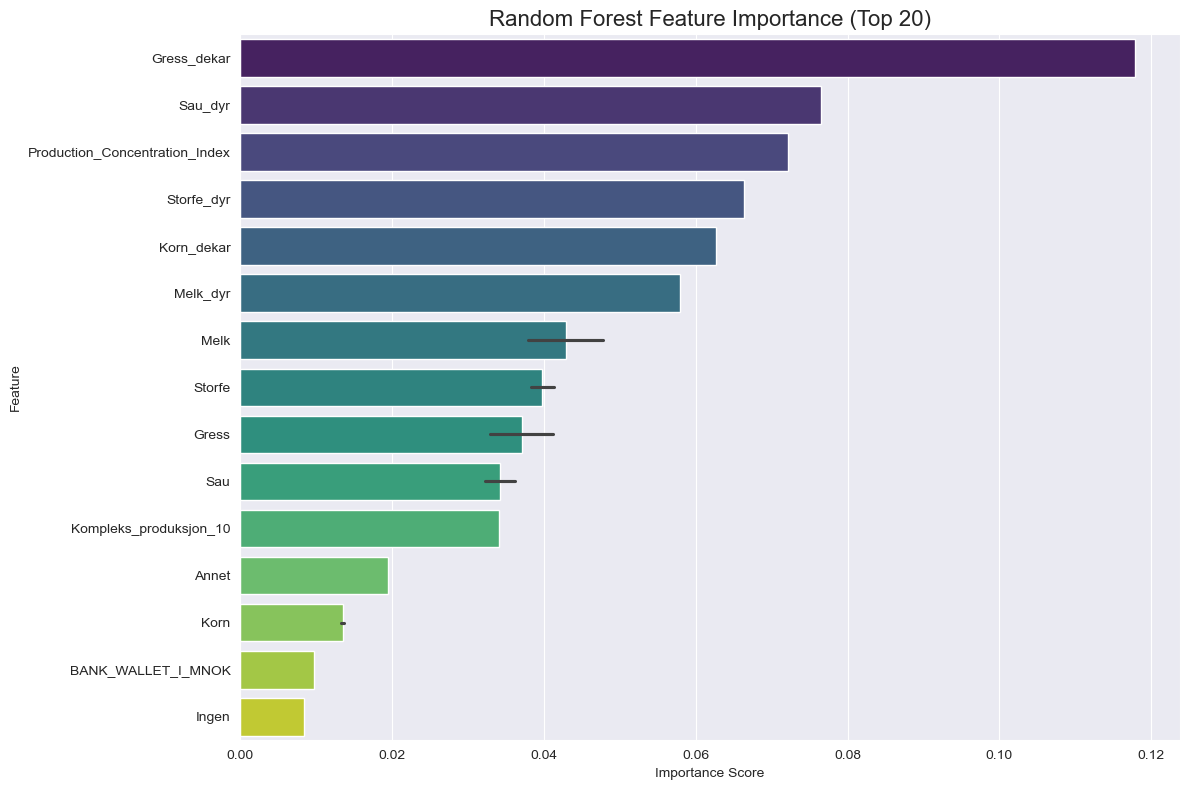

In [4]:
# --- 1. Prepare features and target ---
target_col = 'NY_tilskuddskategori'
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)  # Ensure integer class labels

# --- 2. Split train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")
print(f"Class distribution:\n{y.value_counts(normalize=True)}\n")

# --- 3a. Logistic Regression baseline ---
print("=== Logistic Regression Model ===")
log_reg = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    multi_class='multinomial',
    n_jobs=-1
)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_pred_proba_lr = log_reg.predict_proba(X_test)

print("✅ Logistic Regression Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
try:
    auc_lr = roc_auc_score(y_test, y_pred_proba_lr, multi_class='ovr')
    print("ROC AUC:", auc_lr)
except:
    print("ROC AUC cannot be computed (too many classes or imbalanced)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# --- 3b. Random Forest baseline ---
print("\n=== Random Forest Model ===")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)

print("✅ Random Forest Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
try:
    auc_rf = roc_auc_score(y_test, y_pred_proba_rf, multi_class='ovr')
    print("ROC AUC:", auc_rf)
except:
    print("ROC AUC cannot be computed (too many classes or imbalanced)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# --- 4. Confusion Matrix Visualization ---
print("\n=== Confusion Matrix Visualization ===")
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- 5. Feature Importance Analysis ---
print("\n=== Feature Importance Analysis ===")
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 Important Features:")
print(importances.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances.head(20), palette='viridis', hue='Feature',)
plt.title('Random Forest Feature Importance (Top 20)', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()